# Baseline
Here is provided the entire procedure of the baseline provided in the Common Code of the repository provided for the project

### Imports

In [20]:
import torch
import cv2
import torchvision.models as models
import torch.nn as nn
import numpy as np
from ultralytics import YOLO
from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt
import time
import torch.nn.functional as F
from transformers import ViTModel

## Classifier
Since the required baseline should have a ViT as classifier, I took the one defined in ViT.py inside the Common Code folder of the original repository

In [21]:
class ROIClassifierViT(nn.Module):
    def __init__(self, num_hoi_classes):
        super().__init__()
        
        # Channel reduction layers - same as ResNet version
        self.first = nn.Conv2d(5, 4, kernel_size=1, stride=1, padding=0, bias=False)
        self.pre_conv = nn.Conv2d(4, 3, kernel_size=1, stride=1, padding=0, bias=False)
        
        # Vision Transformer backbone - using ViT-Base pretrained
        self.backbone = ViTModel.from_pretrained('google/vit-base-patch16-224')
        
        # Classification head - ViT outputs 768-dim features
        self.fc = nn.Linear(768, num_hoi_classes)

        
        
    def forward(self, x):
        # Channel reduction: 5 -> 4 -> 3 channels
        x = self.first(x)
        x = self.pre_conv(x)
        
        # ViT expects inputs in range [0, 1] and specific format
        # Extract features using ViT backbone
        outputs = self.backbone(pixel_values=x)
        features = outputs.last_hidden_state[:, 0]  # Use [CLS] token representation
        
        # Classification
        out = F.sigmoid(self.fc(features))
        return out


In [22]:
class ROIClassifier(nn.Module):
    def __init__(self, num_hoi_classes):
        super().__init__()
      
        self.first = nn.Conv2d(5, 4, kernel_size=1, stride=1, padding=0, bias=False)
        self.pre_conv = nn.Conv2d(4, 3, kernel_size=1, stride=1, padding=0, bias=False)
        
        self.backbone = models.resnet18(pretrained=True)
        self.backbone.fc = nn.Identity()
        
        self.fc = nn.Linear(512, num_hoi_classes)
        
    def forward(self, x):
        
        x = self.first(x)
        x = self.pre_conv(x)         
        features = self.backbone(x)   
        out = F.sigmoid(self.fc(features))
        return out
    
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
      
        self.encoder = nn.Sequential(
            nn.Conv2d(4, 4, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(4),
            nn.ReLU(),
            nn.Conv2d(4, 4, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(4),
            nn.ReLU(),
            nn.Conv2d(4, 4, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(4),
            nn.ReLU(),
            nn.Conv2d(4, 3, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(3),
            nn.ReLU(),
        )
        
        self.decoder = nn.Sequential(
            nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.ConvTranspose2d(3, 4, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(4),
        )
        
        
    def forward(self, x):
        en = self.encoder(x)
        out = self.decoder(en)
  
        return out

### Functions
This part is about creating functions used inside the original baseline. These functions can be found inside the pipeline.py of the Common Code of the original github

In [23]:
def load_yolo_model(model_path):
    # Load your YOLOv11-seg model
    model = YOLO(model_path,verbose=False)
    # model.eval()
    # print(model)
    return model

def yolo_inference(model, image) -> list[dict]:
    """
    image: np.ndarray (HWC, RGB)
    Returns: list of dicts { 'mask': HxW, 'class': int, 'score': float }
    """
    # Convert image to tensor, normalize, etc.
    # input_tensor = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).float() / 255.0
    # with torch.no_grad():
    
    output = model.predict(image,verbose=False)

    # Parse output into masks & classes (depends on repo!)
    detections = parse_yolo_output(output) # function to be implemented
    
    return detections


def found_objects(tool_list, tti_list, classes) -> list | list:
    
    tool_found = []
    tti_found = []
    
    for elem in range(len(classes)):
        if classes[elem] in tool_list:
            tool_found.append(elem)
        if classes[elem] in tti_list:
            tti_found.append(elem)
            
    return tool_found, tti_found



def parse_yolo_output(result) -> list[dict]:
    
    r = result[0]
    if len(result[0].boxes.cls) == 0:
        return []
    if len(result[0].boxes.cls) < 2 :
        return [{'class':int(r.boxes.cls[0].cpu().detach().numpy()) , 'mask': r.masks.data[0].cpu().detach().numpy()}]
    
    tool_list = list(range(0, 12))
    tti_list = list(range(12, 21))

    
    classes = r.boxes.cls
    masks = r.masks.data
    
    tool_found, tti_found = found_objects(tool_list, tti_list, classes)

    l = []
    
    if len(tool_found) == 0:
        for idx in tti_found:
            l.append({'class':int(r.boxes.cls[idx].cpu().detach().numpy()) , 'mask': r.masks.data[idx].cpu().detach().numpy()})
        return l
    
    elif len(tti_found) == 0:

        for idx in tool_found:
            l.append({'class':int(r.boxes.cls[idx].cpu().detach().numpy()) , 'mask': r.masks.data[idx].cpu().detach().numpy()})
        return l
    
    res = []
    
    for idx_tti in tti_found:
        for idx_tool in tool_found:
            # tissue_mask = masks[idx_tti].bool() & (~masks[idx_tool].bool())
            # tool_mask = masks[idx_tool].bool()
            
            tissue_mask = masks[idx_tti]
            tool_mask = masks[idx_tool]
            
            tti_dict = {'class': int(classes[idx_tti].cpu().detach().numpy()) , 'mask' : tissue_mask.int().cpu().detach().numpy()}
            tool_dict = {'class': int(classes[idx_tool].cpu().detach().numpy()) , 'mask':  tool_mask.int().cpu().detach().numpy()}
            
            
            
            
            already_has_tti = False
            for elem in res:
                if elem['class'] == tti_dict['class'] and np.array_equal(elem['mask'], tti_dict['mask']):
                    already_has_tti = True
                    break

            if not already_has_tti:
                res.append(tti_dict)

          
            already_has_tool = False
            for elem in res:
                if elem['class'] == tool_dict['class'] and np.array_equal(elem['mask'], tool_dict['mask']):
                    already_has_tool = True
                    break
            if not already_has_tool:
                res.append(tool_dict)

    return res

tool_classes = list(range(0, 12))

def find_tool_tissue_pairs(detections: list[dict]):
    '''
    incrocia ogni strumento rilevato con ogni tessuto 
    identificato per generare tutte le possibili coppie.
    '''
    
    tools = [d for d in detections if d['class'] in tool_classes]
    tissues = [d for d in detections if d['class'] not in tool_classes]
    pairs = []
    for s in tools:
        for o in tissues:
            pairs.append({'tool': s, 'tissue': o})
    return pairs


def extract_union_roi(image, tool_mask, tissue_mask, depth_map=None):
    '''
    Combina la maschera dello strumento con quella del tessuto per calcolare la regione rettangolare minima 
    (Bounding Box) che racchiude entrambi. Ritaglia l'immagine RGB e concatena ad essa sia la profondità che 
    le maschere fondi, creando un tensore a 5 canali (RGB + Depth + Mask)
    '''

    combined_mask = (tool_mask + tissue_mask).clip(0, 1).astype('uint8') #before astype
    x, y, w, h = cv2.boundingRect(combined_mask)
    roi = image[y:y+h, x:x+w]
  

    if depth_map is not None:
        depth_roi = depth_map[y:y+h, x:x+w]
        roi = np.concatenate([roi, depth_roi[..., None]], axis=-1)  # add depth as extra channel

    merged_mask = cv2.bitwise_or(tool_mask, tissue_mask)
    merged_mask = merged_mask[y:y+h, x:x+w]
    merged_mask = np.expand_dims(merged_mask, axis=-1)
    
    if merged_mask.shape[1] != roi.shape[1] or merged_mask.shape[0] != roi.shape[0]:
        print("MISMATCH")
        return None

    roi = np.concatenate([roi, merged_mask*255], axis=-1)

    return roi



def end_to_end_pipeline(image, yolo_model, depth_model, tti_classifier, device):
    # Step 1: YOLOv11-seg and depth estimation
  
    detections = yolo_inference(yolo_model, image)

    # depth_map = depth_model(image)
    depth_map = np.array(depth_model(image)["depth"])
    

    # depth_map = np.array(depth_model(Image.fromarray(image))["depth"])

    # Step 2: Pairing
    pairs = find_tool_tissue_pairs(detections)

    image = cv2.imread(image,cv2.IMREAD_COLOR)
   
    
    tti_predictions = []

    for pair in pairs:
        tool_mask = pair['tool']['mask']
        tissue_mask = pair['tissue']['mask']
        roi = extract_union_roi(image, tool_mask, tissue_mask, depth_map)
        if roi is None:
            return [] ,[]
        # Prepare input for ROI classifier
        roi_tensor = torch.from_numpy(roi).permute(2, 0, 1).unsqueeze(0).float() / 255.0
        roi_tensor = F.interpolate(roi_tensor, size=(224, 224), mode='bilinear', align_corners=False)
        roi_tensor = roi_tensor.to(device)
        
        # mean_rgb = [0.485, 0.456, 0.406]
        # std_rgb  = [0.229, 0.224, 0.225]
        # mean_t = torch.tensor(mean_rgb, device=device).view(1, 3, 1, 1)
        # std_t  = torch.tensor(std_rgb, device=device).view(1, 3, 1, 1)
        # roi_tensor[:, :3, :, :] = (roi_tensor[:, :3, :, :] - mean_t) / std_t
       
        tti_classifier.eval()
        with torch.no_grad():
            tti_logits = tti_classifier(roi_tensor)
            # tti_logits = torch.sigmoid(tti_classifier(roi_tensor))
            # print(tti_logits)
       
            # tti_logits = tti_logits.item()
            tti_class = torch.argmax(tti_logits, dim=1).item()
            tti_score = torch.softmax(tti_logits, dim=1).max().item()
            # if tti_logits >= 0.5:
            #     tti_class = 1
            # else:
            #     tti_class = 0
            # tti_score = tti_logits

        # Save ROI result
        tti_predictions.append({
            'tool': pair['tool'],
            'tissue': pair['tissue'],
            'tti_class': tti_class,
            'tti_score': tti_score
        })

    return detections, tti_predictions


def show_mask_overlay_from_binary_mask(image_bgr, binary_mask, alpha=0.5, mask_color=(1.0, 0.0, 0.0)):

    
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    colored_mask = np.zeros_like(image_rgb)
    colored_mask[..., 0] = mask_color[0]  
    colored_mask[..., 1] = mask_color[1]  
    colored_mask[..., 2] = mask_color[2]  


    overlay = image_rgb.copy()
    indices = binary_mask.astype(bool)
    overlay[indices] = (1 - alpha) * image_rgb[indices] + alpha * colored_mask[indices]

    plt.figure(figsize=(8, 8))
    plt.imshow(overlay)
    plt.axis('off')
    plt.show()
    return cv2.cvtColor((overlay * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)

### And now run!

In [24]:
model = load_yolo_model('best.pt')
image = 'yolo_dataset/images/test/adnansetlc2007_frame000079.png'
pipe = pipeline(task="depth-estimation", model="depth-anything/Depth-Anything-V2-Small-hf")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Loading weights: 100%|██████████| 287/287 [00:00<00:00, 6802.47it/s]


1. Classification with neural network

```text
         immagine
            ↓
         YOLO segmentation
            ↓
         tool + tissue detection
            ↓
         creazione delle coppie tool/tissue
            ↓
         calcolo depth map
            ↓
         ROI = RGB + depth + mask
            ↓
         ROIClassifier
            ↓
         TTI class
```
And this is the version of the pipeline.py of the original github.

In [25]:
tti_class = ROIClassifier(2)
tti_class.load_state_dict(torch.load('ROImodel.pt',map_location=device))
tti_class.to(device)

# tti_class = ROIClassifierViT(2)
# tti_class.load_state_dict(torch.load('Vit2.pt',map_location=device))
# tti_class.to(device)

c:\Users\julia\anaconda3\envs\TTI\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\julia\anaconda3\envs\TTI\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ROIClassifier(
  (first): Conv2d(5, 4, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (pre_conv): Conv2d(4, 3, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): 


TTI:  0


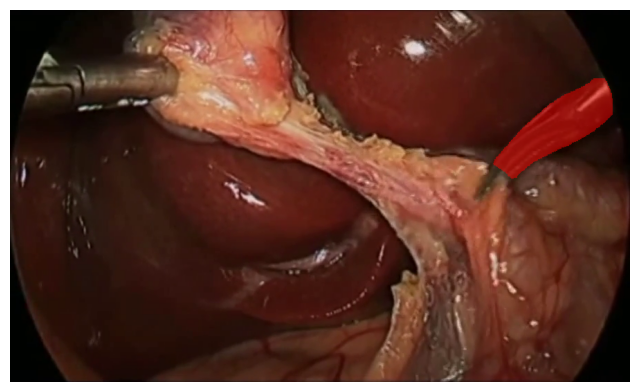

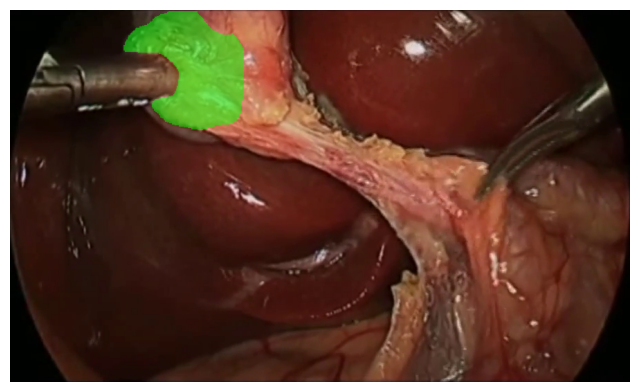

TTI:  1


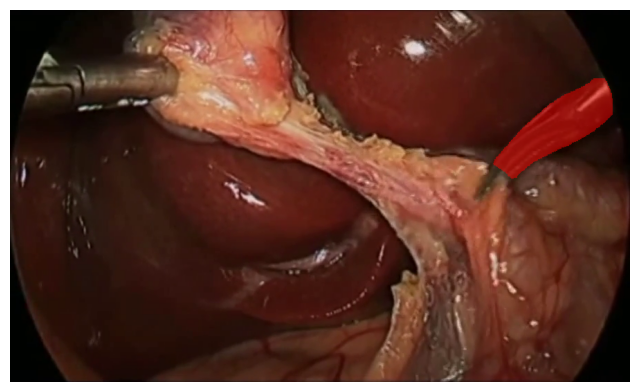

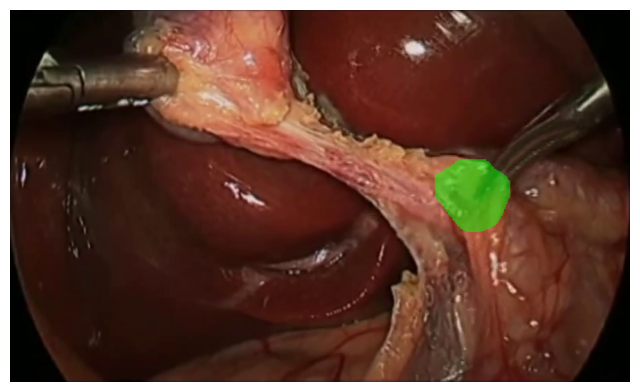

TTI:  1


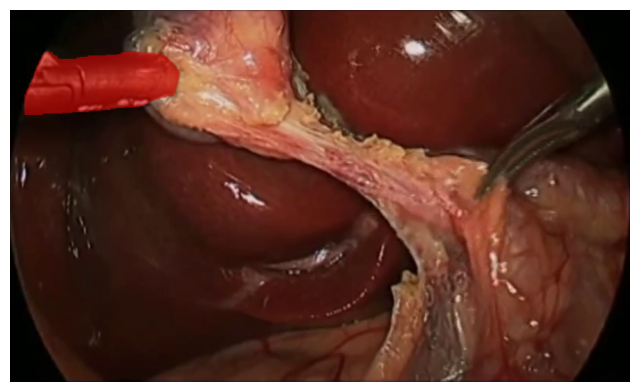

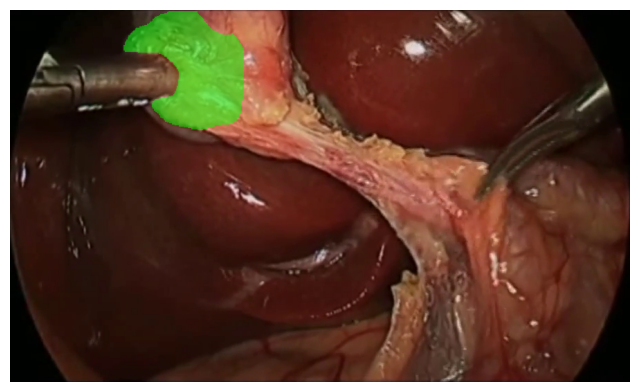

TTI:  0


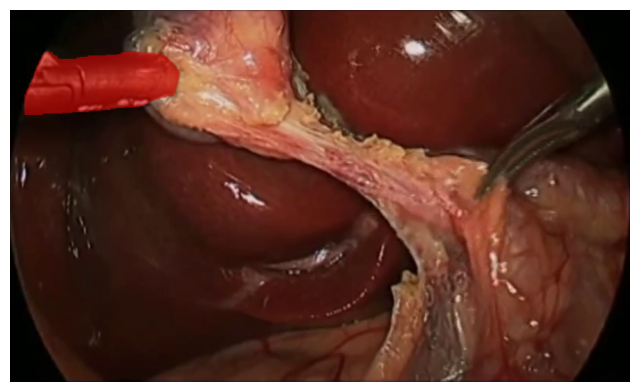

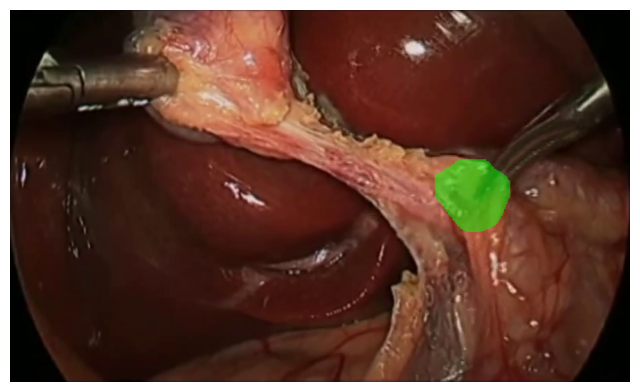

In [26]:
detection , tti_predictions  = end_to_end_pipeline(image,model,pipe,tti_class,device)

print()

# print(tti_predictions)

image_full = cv2.imread(image, cv2.IMREAD_COLOR)


H_full, W_full = image_full.shape[:2]

for i in range(len(tti_predictions)):
    tool_mask_full   = tti_predictions[i]['tool']['mask']    
    tissue_mask_full = tti_predictions[i]['tissue']['mask'] 

    # print("TOOL: " , tti_predictions[i]['tool']['class'])
    # print("TISSUE: " , tti_predictions[i]['tissue']['class'])
    print("TTI: " , tti_predictions[i]['tti_class'])

    tool_mask_resized = cv2.resize(
        tool_mask_full.astype(np.uint8),
        (W_full, H_full),
        interpolation=cv2.INTER_NEAREST
    )
    tissue_mask_resized = cv2.resize(
        tissue_mask_full.astype(np.uint8),
        (W_full, H_full),
        interpolation=cv2.INTER_NEAREST
    )


    show_mask_overlay_from_binary_mask(image_full, tool_mask_resized, mask_color=(1.0, 0.0, 0.0))

    show_mask_overlay_from_binary_mask(image_full, tissue_mask_resized, mask_color=(0.0, 1.0, 0.0))
